# Tool-call audit of his.txt

Build the CSV once, from the `material_agent` directory:

```bash
python -m src.workflow_audit.history_parser <his.txt> -o src/workflow_audit/outputs/tool_calls.csv
```

Then run the cells below — they read only `outputs/tool_calls.csv`.

A round = one agent turn. Rounds with no real tool calls (a boss turn, or a worker Q&A turn) appear as a single **placeholder row** with an empty `tool`; `real` below excludes those.

In [ ]:
import pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv("outputs/production_run_27-05-2026_fork_16_07_2026_tool_calls.csv")
real = df[df["tool"].fillna("") != ""]              # exclude zero-tool placeholder rows
all_rounds = sorted(df["round"].unique())
n_empty = int((df["tool"].fillna("") == "").sum())
print(len(real), "real tool calls across", len(all_rounds), "rounds", f"({n_empty} zero-tool rounds)")
df.head()

4481 real tool calls across 302 rounds (1 zero-tool rounds)


,round,agent,tool,calc_type,outcome,round_start_h,round_start_raw,line_no
0,1,supervisor,inspect_my_canvas,NaN,success,0.0,0:00:00.065060.,14
1,1,supervisor,read_my_canvas,NaN,success,0.0,0:00:00.065060.,28
2,1,supervisor,inspect_explog,NaN,success,0.0,0:00:00.065060.,43
3,2,worker,check_time,NaN,success,NaN,NaN,152
4,2,worker,arXiv_search,NaN,success,NaN,NaN,166


## Session restarts
`session` counts process relaunches: invoke.py writes a "Session started" banner into the log on every launch, including crash recovery, so a restart shows up as `session` incrementing while `round` stays put (or barely moves). The vertical dashed lines added to the round-indexed plots below mark the round each restart resumed into.

In [ ]:
session_starts = df.groupby("session")["round"].min()
restart_rounds = session_starts.iloc[1:]   # skip session 1 -- that's round 1, not a restart
print(f"{len(restart_rounds)} restart(s) detected")
display(restart_rounds.rename("round"))

def mark_sessions(ax):
    """Overlay a black line + label at each round a new session (process
    relaunch, incl. crash recovery) resumed into."""
    for session, round_ in restart_rounds.items():
        ax.axvline(round_, color="black", linestyle="--", linewidth=1, alpha=0.7)
        ax.annotate(f"s{session}", (round_, 1), xycoords=("data", "axes fraction"),
                    color="black", fontsize=7, ha="center", va="bottom", annotation_clip=False)

## Per-round × tool counts
Zero-tool rounds appear as all-zero rows (reindexed over every round).

In [46]:
pivot = (real.pivot_table(index="round", columns="tool", values="line_no",
                         aggfunc="count", fill_value=0)
             .reindex(all_rounds, fill_value=0))
display(pivot)

tool,OER_data_analasis_v2,arXiv_search,browse_df,check_queue_status,check_time,enter_candidate_in_log,get_candidate_data,get_terminations_ranking,inspect_explog,inspect_my_canvas,list_adsorption_sites,query_explog,read_explog,read_my_canvas,search_artifacts,submit_dft_job,wait_for_update,write_my_canvas,write_report
round,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0
2,0,5,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,2,0
3,0,0,0,0,0,0,0,0,1,1,0,1,0,1,0,0,0,0,0
4,2,0,5,0,0,0,0,0,1,1,0,0,0,2,2,0,0,2,0
5,0,0,0,0,0,0,0,0,1,1,0,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,1,0,1,2,0,5,0,0,0,0,0,1,0,0,0,5,1,2,0
299,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0
300,1,0,0,2,0,5,0,1,0,0,0,3,0,0,0,6,1,2,0


## Calls resolved by agent

tool,OER_data_analasis_v2,arXiv_search,browse_df,check_queue_status,check_time,enter_candidate_in_log,get_candidate_data,get_terminations_ranking,inspect_explog,inspect_my_canvas,list_adsorption_sites,query_explog,read_explog,read_my_canvas,search_artifacts,submit_dft_job,wait_for_update,write_my_canvas,write_report
agent,,,,,,,,,,,,,,,,,,,
supervisor,0,0,0,32,0,0,0,0,103,108,0,290,0,132,0,0,0,0,0
worker,81,26,54,162,47,366,3,152,47,3,159,960,90,22,9,819,414,386,16


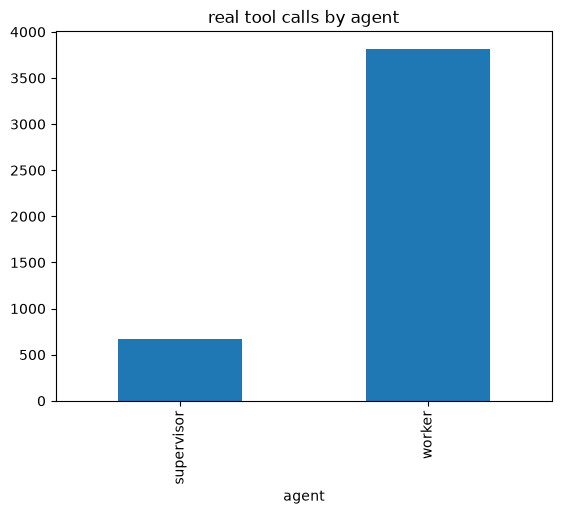

In [47]:
by_agent = real.groupby(["agent", "tool"]).size().unstack(fill_value=0)
display(by_agent)
real.groupby("agent").size().plot.bar(title="real tool calls by agent"); plt.show()

## submit_dft_job: calculation type + outcome

In [ ]:
sub = real[real.tool == "submit_dft_job"]
display(sub.groupby(["calc_type", "outcome"]).size().unstack(fill_value=0))
df_sub = sub.groupby(["round", "calc_type"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(13, 4))
bottom = pd.Series(0, index=df_sub.index)
for col in df_sub.columns:
    ax.bar(df_sub.index, df_sub[col], bottom=bottom, label=col, width=1.5)
    bottom = bottom + df_sub[col]
ax.set_title("submissions per round by type")
ax.set_xlabel("round")
ax.legend()
mark_sessions(ax)
plt.tight_layout()
plt.ylim([0, 42])
plt.show()

## All tool calls per round (by tool)

In [ ]:
df_tools = (real.groupby(["round", "tool"]).size().unstack(fill_value=0)
                .reindex(all_rounds, fill_value=0))   # every round, zero-tool rounds as 0
colors = plt.cm.tab20.colors
fig, ax = plt.subplots(figsize=(13, 4))
bottom = pd.Series(0, index=df_tools.index)
for i, col in enumerate(df_tools.columns):
    ax.bar(df_tools.index, df_tools[col], bottom=bottom, label=col, width=1.5, color=colors[i])
    bottom = bottom + df_tools[col]
ax.set_title("all tool calls per round by tool")
ax.set_xlabel("round")
ax.legend(fontsize=7, ncol=2)
mark_sessions(ax)
plt.tight_layout()
plt.ylim([0, 140])
plt.show()

## Outcome / error rate per tool

In [50]:
oc = real.groupby(["tool", "outcome"]).size().unstack(fill_value=0)
oc["error_rate"] = oc.get("error", 0) / oc.sum(axis=1)
display(oc.sort_values("error_rate", ascending=False))

outcome,success,error_rate
tool,,
OER_data_analasis_v2,80,0.0
arXiv_search,26,0.0
browse_df,54,0.0
check_queue_status,194,0.0
check_time,47,0.0
enter_candidate_in_log,366,0.0
get_candidate_data,3,0.0
get_terminations_ranking,135,0.0
inspect_explog,150,0.0


## Time: round duration & activity
Durations use only timestamped (supervisor/boss) rounds — worker rounds carry no timestamp.

In [ ]:
ts = (df.dropna(subset=["round_start_h"]).drop_duplicates("round")
        [["round", "round_start_h"]].sort_values("round"))
ts["duration_h"] = ts["round_start_h"].diff().shift(-1)
ax1 = ts.plot(x="round", y="duration_h", figsize=(13, 4), title="round duration (h, timestamped rounds)")
mark_sessions(ax1)
plt.show()
ax2 = real.groupby("round").size().plot(figsize=(13, 4), title="real tool calls per round")
mark_sessions(ax2)
plt.show()